# Лабораторная работа №4. Часть 2
## Обучение интеллектуального агента для игры Snake

**Группа:** 71 (1)
**Вариант:** 13 (Easy - Snake)
**Критерий успеха:** Агент должен жить в среднем более 30 секунд (набирать более 10-15 очков).

### Метод решения: Нейроэволюция
Мы не используем обучение с учителем или Q-Learning. Мы используем **Генетический Алгоритм** для эволюции весов нейронной сети. 

Нейросеть принимает на вход информацию об окружении (сенсоры) и выдает действие (поворот). ГА отбирает те сети, которые набрали больше очков.

## Теоретическая справка

**1. Архитектура Агента:**
- **Сенсоры (Входной слой):** Змея «видит» мир относительно своей головы. 
    - Есть ли опасность (стена/хвост) прямо, слева или справа? (3 нейрона)
    - В какой стороне еда относительно головы? (4 нейрона: Слева, Справа, Впереди, Сзади/Внизу)
    - Текущее направление движения (4 нейрона)
- **Скрытый слой:** Обработка признаков (ReLu активация).
- **Выходной слой (Действие):** 3 нейрона (Softmax/Argmax). Индекс нейрона с максимальным значением определяет действие: [0: Влево, 1: Прямо, 2: Вправо].

**2. Функция приспособленности (Fitness):**
Чтобы змея не просто жила, но и ела, фитнес-функция складывается из:
$$ Fitness = (Score \times 1000) + (Steps) + (Rewards_{distance}) $$
- Бонус за съеденное яблоко.
- Бонус за каждый шаг (время жизни).
- **Shaping Reward:** Награда за приближение к яблоку и штраф за удаление (помогает избежать зацикливания).

### 1. Установка зависимостей

In [112]:
!pip install numpy matplotlib


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [113]:
import numpy as np
import random
import json
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output

%matplotlib inline

# Фиксация сида
SEED = 13
np.random.seed(SEED)
random.seed(SEED)

## 2. Игровая среда (Environment)

Реализация логики игры «Змейка» без графического интерфейса для ускоренного обучения.

In [114]:
class SnakeGame:
    def __init__(self, width=20, height=20):
        self.w = width
        self.h = height
        
    def reset(self):
        # Старт в центре
        self.snake = [(self.w // 2, self.h // 2)]
        # Стартовое направление случайное, чтобы агент не переобучался под одно
        self.direction = random.choice([(0, -1), (0, 1), (1, 0), (-1, 0)])
        self.food = self._spawn_food()
        self.score = 0
        self.steps = 0
        # Таймер голода: если змея долго не ест, она умирает (защита от бесконечных циклов)
        self.starvation = 0
        self.max_starvation = 100 + (len(self.snake) * 2)
        return self._get_state()
    
    def _spawn_food(self):
        while True:
            f = (random.randint(0, self.w - 1), random.randint(0, self.h - 1))
            if f not in self.snake:
                return f

    def step(self, action):
        # action: 0 - Left, 1 - Straight, 2 - Right (Относительно головы)
        
        # Определяем новое направление
        # Порядок: Up, Right, Down, Left
        clock_wise = [(0, -1), (1, 0), (0, 1), (-1, 0)]
        current_idx = clock_wise.index(self.direction)
        
        if action == 0: # Left turn
            new_dir = clock_wise[(current_idx - 1) % 4]
        elif action == 2: # Right turn
            new_dir = clock_wise[(current_idx + 1) % 4]
        else: # Straight
            new_dir = self.direction
            
        self.direction = new_dir
        
        # Двигаем голову
        head = self.snake[0]
        new_head = (head[0] + self.direction[0], head[1] + self.direction[1])
        
        # Проверка коллизий (Стены или Хвост)
        if (new_head[0] < 0 or new_head[0] >= self.w or
            new_head[1] < 0 or new_head[1] >= self.h or
            new_head in self.snake[:-1]): # Хвост еще не сдвинулся, врезаться в кончик хвоста нельзя
            return self._get_state(), -10, True # Game Over
        
        # Расчет награды за расстояние (Shaping Reward)
        dist_old = abs(head[0] - self.food[0]) + abs(head[1] - self.food[1])
        dist_new = abs(new_head[0] - self.food[0]) + abs(new_head[1] - self.food[1])
        
        reward = 0
        if dist_new < dist_old:
            reward = 1  # Идем к еде
        else:
            reward = -1.5 # Уходим от еды (штраф чуть больше, чтобы не крутилась)
            
        # Движение
        self.snake.insert(0, new_head)
        
        # Еда
        if new_head == self.food:
            self.score += 1
            reward = 20 # Большая награда за еду
            self.food = self._spawn_food()
            self.starvation = 0
            self.max_starvation = 100 + (len(self.snake) * 3)
        else:
            self.snake.pop()
            self.starvation += 1
            
        self.steps += 1
        
        # Смерть от голода
        if self.starvation >= self.max_starvation:
            return self._get_state(), -10, True
            
        return self._get_state(), reward, False

    def _get_state(self):
        # Формируем вектор признаков (11 входов)
        head = self.snake[0]
        
        # Точки вокруг головы для проверки опасности
        clock_wise = [(0, -1), (1, 0), (0, 1), (-1, 0)]
        idx = clock_wise.index(self.direction)
        
        p_straight = (head[0] + clock_wise[idx][0], head[1] + clock_wise[idx][1])
        p_right = (head[0] + clock_wise[(idx + 1) % 4][0], head[1] + clock_wise[(idx + 1) % 4][1])
        p_left = (head[0] + clock_wise[(idx - 1) % 4][0], head[1] + clock_wise[(idx - 1) % 4][1])
        
        def is_danger(p):
            return 1 if (p[0] < 0 or p[0] >= self.w or p[1] < 0 or p[1] >= self.h or p in self.snake) else 0
            
        state = [
            # 1. Опасность (3 сенсора)
            is_danger(p_straight),
            is_danger(p_right),
            is_danger(p_left),
            
            # 2. Направление движения (4 сенсора - one hot like)
            1 if self.direction[0] == -1 else 0, # Moving Left
            1 if self.direction[0] == 1 else 0,  # Moving Right
            1 if self.direction[1] == -1 else 0, # Moving Up
            1 if self.direction[1] == 1 else 0,  # Moving Down
            
            # 3. Направление еды относительно головы (4 сенсора)
            1 if self.food[0] < head[0] else 0, # Food Left
            1 if self.food[0] > head[0] else 0, # Food Right
            1 if self.food[1] < head[1] else 0, # Food Up
            1 if self.food[1] > head[1] else 0  # Food Down
        ]
        
        return np.array(state)


## 3. Нейросеть (Мозг Агента)

Простая полносвязная сеть: 
**Input (11)** -> **Hidden (16)** -> **Output (3)**

Входы расширены до 11 признаков для лучшей ориентации в пространстве.

In [115]:
class Brain:
    def __init__(self, input_size=11, hidden_size=16, output_size=3):
        self.W1 = np.random.randn(input_size, hidden_size)
        self.b1 = np.random.randn(hidden_size)
        self.W2 = np.random.randn(hidden_size, output_size)
        self.b2 = np.random.randn(output_size)
        
    def predict(self, x):
        # Layer 1 (ReLU)
        h = np.maximum(0, np.dot(x, self.W1) + self.b1)
        # Output (Linear -> Argmax)
        out = np.dot(h, self.W2) + self.b2
        return np.argmax(out)

    def get_genes(self):
        return [self.W1, self.b1, self.W2, self.b2]
    
    def set_genes(self, genes):
        self.W1, self.b1, self.W2, self.b2 = genes

## 4. Генетические операторы

**Мутация:** Добавляет Гауссов шум к весам. Это позволяет агенту "нащупывать" градиент улучшения.
**Скрещивание:** Равномерное скрещивание (каждый вес с 50% вероятностью берется от одного из родителей).

In [116]:
def mutate(brain, rate=0.05, scale=0.1):
    genes = brain.get_genes()
    new_genes = []
    for g in genes:
        # Маска мутации
        mask = np.random.random(g.shape) < rate
        # Шум
        noise = np.random.randn(*g.shape) * scale
        new_genes.append(g + mask * noise)
    
    child = Brain()
    child.set_genes(new_genes)
    return child

def crossover(brain1, brain2):
    g1 = brain1.get_genes()
    g2 = brain2.get_genes()
    new_genes = []
    for i in range(len(g1)):
        mask = np.random.random(g1[i].shape) > 0.5
        new_genes.append(np.where(mask, g1[i], g2[i]))
        
    child = Brain()
    child.set_genes(new_genes)
    return child

## 5. Обучение

Запускаем эволюцию. Используем Элитизм (лучшие 10 всегда выживают) и большой размер популяции для разнообразия.

Начинаем обучение... Пожалуйста, подождите.
Gen   0: Max Fit=1113, Max Score=1
Gen   5: Max Fit=2065, Max Score=2
Gen  10: Max Fit=2140, Max Score=2
Gen  15: Max Fit=1116, Max Score=1
Gen  20: Max Fit=2151, Max Score=2
Gen  25: Max Fit=1122, Max Score=1
Gen  30: Max Fit=2264, Max Score=2
Gen  35: Max Fit=1179, Max Score=1
Gen  40: Max Fit=2088, Max Score=2
Gen  45: Max Fit=3201, Max Score=3
Gen  50: Max Fit=4254, Max Score=4
Gen  55: Max Fit=7361, Max Score=7
Gen  60: Max Fit=7437, Max Score=7
Gen  65: Max Fit=10705, Max Score=10
Gen  70: Max Fit=17957, Max Score=17
Gen  75: Max Fit=20142, Max Score=19
Gen  80: Max Fit=27615, Max Score=26
Gen  85: Max Fit=42611, Max Score=40
Gen  90: Max Fit=47161, Max Score=44
Gen  95: Max Fit=53518, Max Score=50
Gen  99: Max Fit=74496, Max Score=70
Обучение завершено. Лучший счет: 70


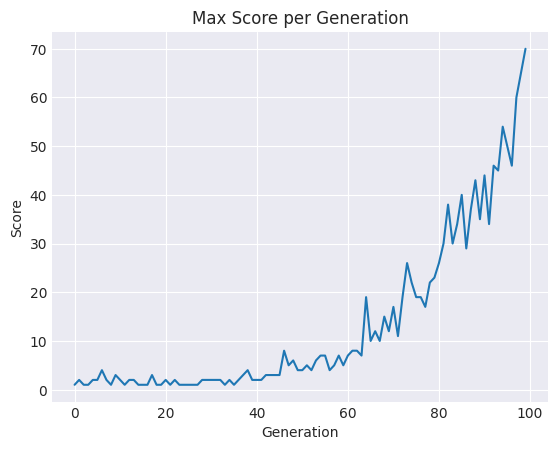

In [117]:
POP_SIZE = 200
GENERATIONS = 100
ELITE_SIZE = 10

env = SnakeGame()
population = [Brain() for _ in range(POP_SIZE)]

history_max = []
history_score = []

best_overall_score = 0
best_genes_json = None

print("Начинаем обучение... Пожалуйста, подождите.")

for gen in range(GENERATIONS):
    fitness_scores = []
    scores_raw = []
    
    for brain in population:
        state = env.reset()
        done = False
        total_reward = 0
        
        while not done:
            action = brain.predict(state)
            state, reward, done = env.step(action)
            total_reward += reward
        
        # Fitness function
        # Приоритет 1: Очки (env.score)
        # Приоритет 2: Время жизни (env.steps)
        fit = (env.score * 1000) + env.steps + total_reward
        if fit < 0: fit = 0
        
        fitness_scores.append(fit)
        scores_raw.append(env.score)
        
    # Статистика поколения
    max_fit = max(fitness_scores)
    max_score = max(scores_raw)
    history_max.append(max_fit)
    history_score.append(max_score)
    
    # Сохраняем лучшего
    best_idx = np.argmax(fitness_scores)
    if max_score > best_overall_score:
        best_overall_score = max_score
        # Сериализуем веса для JS
        w = population[best_idx].get_genes()
        best_genes_json = [x.tolist() for x in w]
        
    if gen % 5 == 0 or gen == GENERATIONS - 1:
        print(f"Gen {gen:3d}: Max Fit={int(max_fit)}, Max Score={max_score}")
        
    # Сортировка для селекции
    sorted_pop_indices = np.argsort(fitness_scores)[::-1]
    sorted_pop = [population[i] for i in sorted_pop_indices]
    
    # Формирование новой популяции
    new_pop = []
    
    # 1. Элита (копируем без мутаций)
    new_pop.extend(sorted_pop[:ELITE_SIZE])
    
    # 2. Дети
    # Отбираем родителей из топ 30%
    parents_pool = sorted_pop[:int(POP_SIZE * 0.3)]
    
    while len(new_pop) < POP_SIZE:
        p1 = random.choice(parents_pool)
        p2 = random.choice(parents_pool)
        child = crossover(p1, p2)
        # Слабая мутация для уточнения
        child = mutate(child, rate=0.05, scale=0.2)
        new_pop.append(child)
        
    population = new_pop

print(f"Обучение завершено. Лучший счет: {best_overall_score}")

plt.plot(history_score)
plt.title("Max Score per Generation")
plt.xlabel("Generation")
plt.ylabel("Score")
plt.show()

## 6. Экспорт и Визуализация

Создаем красивый `index.html`, в который вшиваем веса обученной нейросети. 
Интерфейс содержит:
- Таймер (для проверки условия > 30 сек).
- Счетчик очков.
- Кнопку рестарта.

In [118]:
js_weights = json.dumps(best_genes_json)

html_template = f"""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Neural Snake AI</title>
<style>
    :root {{
        --bg-color: #23272a;
        --panel-color: #2c2f33;
        --text-color: #eceff4;
        --accent-color: #7289da;
        --snake-body: #88c0d0;
        --snake-head: #eceff4;
        --food-color: #bf616a;
        --danger-color: #d08770;
    }}

    body {{
        background-color: var(--bg-color);
        color: var(--text-color);
        font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Helvetica, Arial, sans-serif;
        display: flex;
        flex-direction: column;
        align-items: center;
        justify-content: center;
        height: 100vh;
        margin: 0;
        user-select: none;
    }}

    h2 {{
        font-weight: 300;
        letter-spacing: 2px;
        margin-bottom: 20px;
        font-size: 24px;
        opacity: 0.9;
    }}

    /* Stats Panel */
    .stats {{
        display: flex;
        gap: 40px;
        margin-bottom: 15px;
        background: var(--panel-color);
        padding: 10px 30px;
        border-radius: 50px;
        box-shadow: 0 4px 6px rgba(0,0,0,0.3);
        font-size: 16px;
        font-weight: 500;
    }}
    .stat-item span {{
        font-weight: 700;
        color: var(--accent-color);
        margin-left: 8px;
        min-width: 40px;
        display: inline-block;
    }}

    /* Game Canvas */
    canvas {{
        background-color: var(--panel-color);
        border-radius: 8px;
        box-shadow: 0 10px 20px rgba(0,0,0,0.4);
        margin-bottom: 25px;
    }}

    /* Controls */
    .controls {{
        display: flex;
        gap: 10px;
        flex-wrap: wrap;
        justify-content: center;
    }}

    button {{
        background: var(--panel-color);
        color: var(--text-color);
        border: 1px solid rgba(255,255,255,0.1);
        padding: 8px 16px;
        border-radius: 6px;
        cursor: pointer;
        font-size: 13px;
        transition: all 0.2s ease;
        font-weight: 500;
    }}

    button:hover {{
        background: var(--accent-color);
        color: #fff;
        border-color: var(--accent-color);
        transform: translateY(-1px);
    }}

    button:active {{
        transform: translateY(1px);
    }}
</style>
</head>
<body>

<h2>NEURAL SNAKE</h2>

<div class="stats">
    <div class="stat-item">Score: <span id="scoreVal">0</span></div>
    <div class="stat-item">Sim Time: <span id="timeVal">0.0s</span></div>
</div>

<canvas id="game" width="400" height="400"></canvas>

<div class="controls">
    <button onclick="setSpeed(0.5)">x0.5</button>
    <button onclick="setSpeed(1)">x1</button>
    <button onclick="setSpeed(2)">x2</button>
    <button onclick="setSpeed(5)">x5</button>
    <button onclick="setSpeed(100)">MAX</button>
    <button onclick="resetGame()" style="border-color: var(--danger-color); color:var(--danger-color)">RESET</button>
</div>

<script>
const weights = __WEIGHTS__;
const [W1, b1, W2, b2] = weights;

const canvas = document.getElementById("game");
const ctx = canvas.getContext("2d");
const grid = 20;
const cols = canvas.width / grid;
const rows = canvas.height / grid;

// DOM Elements
const scoreEl = document.getElementById('scoreVal');
const timeEl = document.getElementById('timeVal');

// ---------------- SPEED CONTROL ----------------
const BASE_STEP_TIME = 150; // Время одного шага в мс (как бы 1 "тик" симуляции)
let speedMultiplier = 1;
let accumulator = 0;
let lastTime = performance.now();

function setSpeed(v){{
    speedMultiplier = Math.max(0.2, Math.min(100, v));
}}

// ---------------- GAME STATE ----------------
let snake, dir, food, dead;
let score = 0;
let steps = 0; // Считаем шаги симуляции

// ---------------- AI ----------------
function predict(input) {{
    let h = [];
    for (let i = 0; i < b1.length; i++) {{
        let s = b1[i];
        for (let j = 0; j < input.length; j++) s += input[j] * W1[j][i];
        h.push(Math.max(0, s));
    }}

    let out = [];
    for (let i = 0; i < b2.length; i++) {{
        let s = b2[i];
        for (let j = 0; j < h.length; j++) s += h[j] * W2[j][i];
        out.push(s);
    }}
    return out.indexOf(Math.max(...out));
}}

// ---------------- FEATURES ----------------
function getFeatures() {{
    let h = snake[0];
    const dirs = [{{x:0,y:-1}},{{x:1,y:0}},{{x:0,y:1}},{{x:-1,y:0}}];
    let idx = dirs.findIndex(d => d.x===dir.x && d.y===dir.y);

    function bad(p){{
        if(p.x<0||p.y<0||p.x>=cols||p.y>=rows) return 1;
        return snake.some(s=>s.x===p.x&&s.y===p.y)?1:0;
    }}

    let f=dirs[idx], r=dirs[(idx+1)%4], l=dirs[(idx+3)%4];

    return [
        bad({{x:h.x+f.x,y:h.y+f.y}}),
        bad({{x:h.x+r.x,y:h.y+r.y}}),
        bad({{x:h.x+l.x,y:h.y+l.y}}),
        dir.x==-1?1:0, dir.x==1?1:0,
        dir.y==-1?1:0, dir.y==1?1:0,
        food.x<h.x?1:0, food.x>h.x?1:0,
        food.y<h.y?1:0, food.y>h.y?1:0
    ];
}}

// ---------------- GAME LOGIC ----------------
function resetGame(){{
    snake=[{{x:10,y:10}},{{x:10,y:11}},{{x:10,y:12}}];
    dir={{x:0,y:-1}};
    dead=false;
    score=0;
    steps=0;
    updateStats();
    spawnFood();
}}

function spawnFood(){{
    do{{
        food={{x:Math.floor(Math.random()*cols),y:Math.floor(Math.random()*rows)}};
    }}while(snake.some(s=>s.x===food.x&&s.y===food.y));
}}

function step(){{
    if(dead) return;

    // Считаем шаги
    steps++;

    let a=predict(getFeatures());
    const dirs=[{{x:0,y:-1}},{{x:1,y:0}},{{x:0,y:1}},{{x:-1,y:0}}];
    let i=dirs.findIndex(d=>d.x===dir.x&&d.y===dir.y);
    if(a===0) i=(i+3)%4; // Turn Left
    if(a===2) i=(i+1)%4; // Turn Right
    dir=dirs[i];

    let h={{x:snake[0].x+dir.x,y:snake[0].y+dir.y}};
    
    // Check Collision
    if(h.x<0||h.y<0||h.x>=cols||h.y>=rows||snake.some(s=>s.x===h.x&&s.y===h.y)){{
        dead=true;
        return;
    }}

    snake.unshift(h);
    if(h.x===food.x&&h.y===food.y) {{
        score++;
        spawnFood();
    }} else {{
        snake.pop();
    }}
}}

function updateStats() {{
    scoreEl.innerText = score;
    // Время = количество шагов * время одного шага (в секундах)
    let simTime = (steps * BASE_STEP_TIME) / 1000;
    timeEl.innerText = simTime.toFixed(1) + "s";
}}

// ---------------- DRAW ----------------
function draw(){{
    // Clear
    ctx.fillStyle="#2c2f33"; 
    ctx.fillRect(0,0,canvas.width,canvas.height);

    // Draw Food
    ctx.fillStyle="#bf616a"; // Soft Red
    ctx.beginPath();
    ctx.roundRect(food.x*grid + 2, food.y*grid + 2, grid-4, grid-4, 4);
    ctx.fill();

    // Draw Snake
    snake.forEach((s,i)=>{{ 
        ctx.fillStyle = i===0 ? "#eceff4" : "#88c0d0"; // Head: White, Body: Soft Blue
        ctx.beginPath();
        let pad = i===0 ? 0 : 1;
        ctx.rect(s.x*grid + pad, s.y*grid + pad, grid - pad*2, grid - pad*2);
        ctx.fill();
    }});

    if(dead){{
        ctx.fillStyle="rgba(0,0,0,0.5)";
        ctx.fillRect(0,0,canvas.width,canvas.height);
        
        ctx.fillStyle="#fff";
        ctx.font="bold 30px sans-serif";
        ctx.textAlign = "center";
        ctx.fillText("GAME OVER", canvas.width/2, canvas.height/2);
        ctx.font="16px sans-serif";
        ctx.fillText("Score: " + score, canvas.width/2, canvas.height/2 + 30);
    }}
}}

// ---------------- MAIN LOOP ----------------
function loop(now){{
    let dt = now - lastTime;
    lastTime = now;
    accumulator += dt * speedMultiplier;

    while(accumulator >= BASE_STEP_TIME){{
        step();
        accumulator -= BASE_STEP_TIME;
    }}

    // Вызываем updateStats только здесь, чтобы UI обновлялся синхронно с шагами
    updateStats();
    draw();
    requestAnimationFrame(loop);
}}

resetGame();
requestAnimationFrame(loop);
</script>
</body>
</html>
"""

html_template = html_template.replace("__WEIGHTS__", js_weights)

with open("index.html","w",encoding="utf-8") as f:
    f.write(html_template)

print("index.html создан (Время симуляции)")

index.html создан (Время симуляции)
